# Notebook 161: テキストのトークン化 — BPE・WordPiece・SentencePiece

---

### このノートブックの位置づけ

**難易度: ★★★☆☆ | 所要時間: 90-120 分 | カテゴリ: 言語モデル**

現代の言語モデル（BERT, GPT, T5 など）は、テキストを直接処理するのではなく、
まず**トークン化（tokenization）**を行います。このノートブックでは、
最も重要なサブワードトークン化手法である **BPE**, **WordPiece**, **SentencePiece** を
理論と実装の両面から学びます。

### 学習目標

- [ ] 文字レベル/単語レベル/サブワードの動機と使い分けを説明できる
- [ ] BPEアルゴリズムをスクラッチ実装できる
- [ ] WordPieceとBPEの差異（尤度ベース vs 頻度ベース）を理解できる
- [ ] SentencePieceの概要と言語非依存性を説明できる
- [ ] HuggingFace tokenizersライブラリを使える
- [ ] 特殊トークン（[CLS], [SEP], [MASK], [PAD], [BOS], [EOS]）の役割を説明できる

### 前提知識

- ✅ Notebook 151（Word2Vec と静的埋め込み）
- ✅ Python の基礎（文字列操作、辞書、Counter）

---

## 目次

1. [環境セットアップ](#1-環境セットアップ)
2. [なぜサブワードが必要か？](#2-なぜサブワードが必要か)
3. [BPEアルゴリズムのスクラッチ実装](#3-bpeアルゴリズムのスクラッチ実装)
4. [WordPieceとの比較](#4-wordpieceとの比較)
5. [SentencePieceの概要](#5-sentencieceの概要)
6. [HuggingFace tokenizersとの比較](#6-huggingface-tokenizersとの比較)
7. [特殊トークンの役割](#7-特殊トークンの役割)
8. [語彙構築の実験](#8-語彙構築の実験)
9. [まとめ・チートシート・よくある間違い](#9-まとめチートシートよくある間違い)
10. [自己評価クイズ](#10-自己評価クイズ)

---

## 1. 環境セットアップ

In [1]:
# ============================================================
# セクション1: 環境セットアップ
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import copy
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
def setup_japanese_font():
    """環境に応じて日本語フォントを設定する。"""
    import matplotlib
    # macOS
    japanese_fonts = ['Hiragino Sans', 'Hiragino Maru Gothic Pro',
                      'Arial Unicode MS', 'Yu Gothic', 'Meiryo',
                      'IPAexGothic', 'Noto Sans CJK JP', 'sans-serif']
    for font in japanese_fonts:
        try:
            matplotlib.font_manager.findfont(font, fallback_to_default=False)
            plt.rcParams['font.family'] = font
            break
        except Exception:
            continue
    plt.rcParams['axes.unicode_minus'] = False

setup_japanese_font()
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# 再現性のためのシード
np.random.seed(42)

# transformers ライブラリ（オプション依存）
try:
    from transformers import AutoTokenizer
    HAS_TRANSFORMERS = True
    print("transformers ライブラリ: 利用可能")
except ImportError:
    HAS_TRANSFORMERS = False
    print("transformers ライブラリ: 未インストール（セクション6はスキップされます）")

print("環境セットアップ完了")
print(f"NumPy version: {np.__version__}")

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


transformers ライブラリ: 利用可能
環境セットアップ完了
NumPy version: 1.26.4


---

## 2. なぜサブワードが必要か？

テキストをモデルに入力するには、まず**離散的なトークン列**に変換する必要があります。
その分割方法には大きく3つのアプローチがあり、それぞれ長所と短所があります。

### 2.1 3つのアプローチ

| アプローチ | 例（"unhappiness"） | 語彙サイズ | シーケンス長 |
|-----------|---------------------|-----------|-------------|
| **文字レベル** | `u, n, h, a, p, p, i, n, e, s, s` | ~100 | 非常に長い |
| **単語レベル** | `unhappiness` | ~100,000+ | 短い |
| **サブワード** | `un, happi, ness` | ~30,000 | 適度 |

### 2.2 文字レベルの問題

- 語彙サイズは小さい（英語なら約100文字）
- しかし、シーケンスが**非常に長くなる** → Transformerの計算量は $O(n^2)$ なので致命的
- 文字単体では意味的な情報がほとんどない

### 2.3 単語レベルの問題

- **OOV（Out-of-Vocabulary）問題**: 学習時に見なかった単語は処理できない
- **語彙爆発**: 形態変化の多い言語では語彙サイズが膨大に
  - 英語: run, runs, running, ran, runner, ... → 全て別トークン
  - 日本語: 食べる, 食べた, 食べない, 食べたい, ... → 活用形が多い
- **低頻度語**: 出現回数が少ない単語の埋め込みは品質が低い

### 2.4 サブワードの解決策

サブワード分割は、上記2つの問題を**ちょうど良いバランス**で解決します：

- 高頻度語はそのまま1トークン（"the", "is" など）
- 低頻度語や未知語はサブワードに分解（"un" + "happi" + "ness"）
- 語彙サイズは制御可能（通常 30,000～50,000）
- 形態素的な情報を自然に捉える

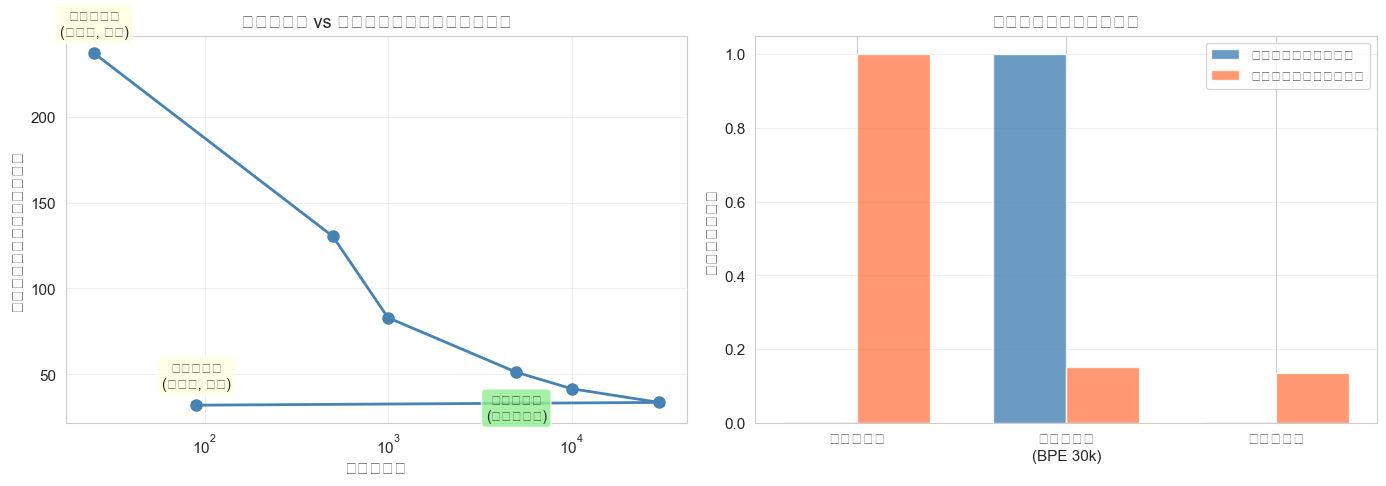

サブワード分割は語彙サイズとシーケンス長のバランスが最も良い
  文字レベル: 語彙=25, シーケンス長=237
  単語レベル: 語彙=30, シーケンス長=32
  サブワード: 語彙=30,000（制御可能）, シーケンス長=適度


In [2]:
# ============================================================
# セクション2.5: 語彙サイズ vs シーケンス長のトレードオフ可視化
# ============================================================

# シミュレーション: 分割の粒度を変えたときの語彙サイズとシーケンス長の関係
# 実際のコーパスを使った概念的なデモ

# デモ用テキスト
sample_text = (
    "The transformer architecture has revolutionized natural language processing. "
    "Tokenization is a fundamental preprocessing step. "
    "Subword tokenization balances vocabulary size and sequence length effectively. "
    "Unknown words can be decomposed into meaningful subword units."
)
words = sample_text.lower().split()

# 各レベルでの語彙サイズとシーケンス長を計算
# 文字レベル
chars = list(sample_text.lower().replace(" ", ""))
char_vocab = len(set(chars))
char_seq_len = len(chars)

# 単語レベル
word_vocab = len(set(words))
word_seq_len = len(words)

# サブワードレベル（概念的な値）
# 実際のBPEでは語彙サイズに応じて変わる
subword_vocab_sizes = [100, 500, 1000, 5000, 10000, 30000, 50000]
# 語彙サイズが大きいほどシーケンスは短くなる（対数的な関係）
subword_seq_lens = [char_seq_len * 0.9,   # ほぼ文字レベル
                    char_seq_len * 0.6,
                    char_seq_len * 0.4,
                    word_seq_len * 1.8,
                    word_seq_len * 1.4,
                    word_seq_len * 1.1,   # ほぼ単語レベル
                    word_seq_len * 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: トレードオフの概念図
ax = axes[0]
vocab_sizes = [char_vocab, 500, 1000, 5000, 10000, 30000, word_vocab * 3]
seq_lengths = [char_seq_len, char_seq_len * 0.55, char_seq_len * 0.35,
               word_seq_len * 1.6, word_seq_len * 1.3, word_seq_len * 1.05,
               word_seq_len]

ax.plot(vocab_sizes, seq_lengths, 'o-', color='steelblue', linewidth=2, markersize=8)

# 各レベルのラベル
ax.annotate('文字レベル\n(語彙小, 列長)', (char_vocab, char_seq_len),
            fontsize=10, ha='center', va='bottom',
            xytext=(0, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.annotate('サブワード\n(バランス良)', (5000, word_seq_len * 1.6),
            fontsize=10, ha='center', va='top',
            xytext=(0, -15), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
ax.annotate('単語レベル\n(語彙大, 列短)', (word_vocab * 3, word_seq_len),
            fontsize=10, ha='center', va='bottom',
            xytext=(0, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('語彙サイズ', fontsize=12)
ax.set_ylabel('シーケンス長（トークン数）', fontsize=12)
ax.set_title('語彙サイズ vs シーケンス長のトレードオフ', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# 右: 3つのアプローチの比較棒グラフ
ax = axes[1]
approaches = ['文字レベル', 'サブワード\n(BPE 30k)', '単語レベル']
vocab_vals = [char_vocab, 30000, word_vocab * 3]
seq_vals = [char_seq_len, int(word_seq_len * 1.15), word_seq_len]

x = np.arange(len(approaches))
width = 0.35
bars1 = ax.bar(x - width/2, [v / max(vocab_vals) for v in vocab_vals],
               width, label='語彙サイズ（正規化）', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [s / max(seq_vals) for s in seq_vals],
               width, label='シーケンス長（正規化）', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(approaches, fontsize=11)
ax.set_ylabel('正規化された値', fontsize=12)
ax.set_title('各アプローチの特性比較', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("サブワード分割は語彙サイズとシーケンス長のバランスが最も良い")
print(f"  文字レベル: 語彙={char_vocab}, シーケンス長={char_seq_len}")
print(f"  単語レベル: 語彙={word_vocab}, シーケンス長={word_seq_len}")
print(f"  サブワード: 語彙=30,000（制御可能）, シーケンス長=適度")

---

## 3. BPEアルゴリズムのスクラッチ実装

**Byte Pair Encoding (BPE)** は、元々はデータ圧縮アルゴリズムとして提案されました
（Gage, 1994）。Sennrich et al. (2016) がこれをサブワードトークン化に応用し、
現在ではGPT系モデルの標準的なトークン化手法となっています。

### BPE の基本アイデア

1. テキストを文字レベルに分割する（初期語彙）
2. 最も頻度の高い文字ペアを見つける
3. そのペアを1つのトークンにマージする
4. 語彙サイズが目標に達するまで 2-3 を繰り返す

### 具体例

```
初期状態:  l o w </w>  (5回),  l o w e r </w>  (2回),  n e w </w>  (6回)

ステップ1: 最頻ペア (e, w) → 'ew' にマージ
           l o w </w>  (5回),  l o w e r </w>  (2回),  n ew </w>  (6回)

ステップ2: 最頻ペア (n, ew) → 'new' にマージ
           l o w </w>  (5回),  l o w e r </w>  (2回),  new </w>  (6回)

...
```

`</w>` は単語の終端を示す特殊記号です。

In [3]:
# ============================================================
# セクション3.1: BPE学習アルゴリズムの実装
# ============================================================

class BPETokenizer:
    """
    Byte Pair Encoding (BPE) トークナイザのスクラッチ実装。
    
    アルゴリズム:
    1. コーパス中の各単語を文字列に分割し、終端記号 '</w>' を付加
    2. 全ペアの出現頻度を計算
    3. 最頻ペアをマージして1つの新しいトークンにする
    4. 目標語彙サイズに達するまで 2-3 を繰り返す
    
    Attributes:
        vocab_size: int - 目標語彙サイズ
        merges: list - 学習されたマージ操作のリスト
        vocab: set - 最終的な語彙
        merge_history: list - マージの履歴（可視化用）
    """
    
    def __init__(self, vocab_size=300):
        """BPEトークナイザを初期化する。"""
        self.vocab_size = vocab_size
        self.merges = []          # マージルールのリスト: [(a, b), ...]
        self.vocab = set()        # 最終語彙
        self.merge_history = []   # 各ステップの情報を記録
        self.word_freqs = {}      # 単語 → 頻度
        self.splits = {}          # 単語 → 現在の分割状態
    
    def _build_word_freqs(self, corpus):
        """
        コーパスから単語頻度を構築する。
        各単語は文字のタプルに分割し、終端記号 '</w>' を付加する。
        
        Parameters:
            corpus: list of str - テキストのリスト
        """
        word_counts = Counter()
        for text in corpus:
            # 簡易トークン化: 小文字化 + 空白分割
            tokens = text.lower().split()
            word_counts.update(tokens)
        
        # 各単語を文字に分割 + 終端記号
        self.word_freqs = {}
        self.splits = {}
        for word, freq in word_counts.items():
            # 文字に分割して終端記号を付ける
            chars = list(word) + ['</w>']
            word_key = ' '.join(chars)
            self.word_freqs[word_key] = freq
            self.splits[word_key] = chars
    
    def _get_pair_freqs(self):
        """
        現在の分割状態から、隣接ペアの頻度を計算する。
        
        Returns:
            pair_freqs: Counter - {(tokenA, tokenB): frequency}
        """
        pair_freqs = Counter()
        for word_key, freq in self.word_freqs.items():
            symbols = word_key.split()
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i + 1])
                pair_freqs[pair] += freq
        return pair_freqs
    
    def _merge_pair(self, pair):
        """
        指定されたペアをマージして、word_freqsを更新する。
        
        Parameters:
            pair: tuple - マージするペア (tokenA, tokenB)
        """
        merged = pair[0] + pair[1]
        # 正規表現でペアの出現を置換
        # エスケープが必要な文字を処理
        p0 = re.escape(pair[0])
        p1 = re.escape(pair[1])
        pattern = re.compile(r'(?<!\S)' + p0 + r' ' + p1 + r'(?!\S)')
        
        new_word_freqs = {}
        for word_key, freq in self.word_freqs.items():
            new_key = pattern.sub(merged, word_key)
            new_word_freqs[new_key] = freq
        self.word_freqs = new_word_freqs
    
    def train(self, corpus, verbose=True):
        """
        BPEをコーパスで学習する。
        
        Parameters:
            corpus: list of str - 学習テキストのリスト
            verbose: bool - 途中経過を表示するか
        """
        # ステップ1: 単語頻度の構築
        self._build_word_freqs(corpus)
        
        # 初期語彙: 全文字 + 終端記号
        self.vocab = set()
        for word_key in self.word_freqs:
            for symbol in word_key.split():
                self.vocab.add(symbol)
        
        initial_vocab_size = len(self.vocab)
        if verbose:
            print(f"初期語彙サイズ: {initial_vocab_size}")
            print(f"目標語彙サイズ: {self.vocab_size}")
            print(f"必要なマージ回数: {self.vocab_size - initial_vocab_size}")
            print()
        
        # ステップ2-4: マージの繰り返し
        step = 0
        while len(self.vocab) < self.vocab_size:
            # 全ペアの頻度を計算
            pair_freqs = self._get_pair_freqs()
            
            if not pair_freqs:
                if verbose:
                    print("マージ可能なペアがなくなりました")
                break
            
            # 最頻ペアを選択
            best_pair = pair_freqs.most_common(1)[0]
            pair, freq = best_pair
            
            # マージ実行
            merged_token = pair[0] + pair[1]
            self._merge_pair(pair)
            self.merges.append(pair)
            self.vocab.add(merged_token)
            
            # 履歴の記録
            self.merge_history.append({
                'step': step,
                'pair': pair,
                'merged': merged_token,
                'frequency': freq,
                'vocab_size': len(self.vocab)
            })
            
            step += 1
            
            if verbose and step <= 15:
                print(f"  ステップ {step:>3d}: "
                      f"'{pair[0]}' + '{pair[1]}' → '{merged_token}' "
                      f"(頻度: {freq}, 語彙サイズ: {len(self.vocab)})")
        
        if verbose:
            print(f"\n学習完了: {len(self.merges)} 回のマージ")
            print(f"最終語彙サイズ: {len(self.vocab)}")
    
    def encode(self, text):
        """
        テキストをBPEトークンに分割する。
        
        Parameters:
            text: str - 入力テキスト
        
        Returns:
            tokens: list of str - BPEトークンのリスト
        """
        tokens = []
        words = text.lower().split()
        
        for word in words:
            # 文字に分割 + 終端記号
            word_tokens = list(word) + ['</w>']
            
            # 学習済みマージを順番に適用
            for pair in self.merges:
                merged = pair[0] + pair[1]
                i = 0
                new_tokens = []
                while i < len(word_tokens):
                    if (i < len(word_tokens) - 1 and
                        word_tokens[i] == pair[0] and
                        word_tokens[i + 1] == pair[1]):
                        new_tokens.append(merged)
                        i += 2
                    else:
                        new_tokens.append(word_tokens[i])
                        i += 1
                word_tokens = new_tokens
            
            tokens.extend(word_tokens)
        
        return tokens
    
    def decode(self, tokens):
        """
        BPEトークン列を元のテキストに復元する。
        
        Parameters:
            tokens: list of str - BPEトークンのリスト
        
        Returns:
            text: str - 復元されたテキスト
        """
        # トークンを結合
        text = ''.join(tokens)
        # 終端記号をスペースに置換
        text = text.replace('</w>', ' ')
        return text.strip()


print("BPETokenizer クラスの定義完了")
print("メソッド: train, encode, decode")

BPETokenizer クラスの定義完了
メソッド: train, encode, decode


In [4]:
# ============================================================
# セクション3.2: BPEの学習実行
# ============================================================

# 学習用コーパス
# 英語の簡単なテキスト（パターンが見えるように設計）
corpus = [
    "low low low low low",
    "lower lower",
    "newest newest newest newest newest newest",
    "widest widest widest",
    "new new new new new new new new",
    "the cat sat on the mat",
    "the cat is on the mat",
    "a cat and a dog",
    "the dog sat on the rug",
    "running runner runs run",
    "playing player plays played",
    "unhappy unhappiness happiness happy",
    "tokenization tokenize tokenizer tokens",
    "natural language processing",
    "neural network networks",
]

# BPE の学習（目標語彙サイズ: 80）
bpe = BPETokenizer(vocab_size=80)
bpe.train(corpus, verbose=True)

初期語彙サイズ: 21
目標語彙サイズ: 80
必要なマージ回数: 59

  ステップ   1: 'n' + 'e' → 'ne' (頻度: 20, 語彙サイズ: 22)
  ステップ   2: 't' + '</w>' → 't</w>' (頻度: 16, 語彙サイズ: 23)
  ステップ   3: 'ne' + 'w' → 'new' (頻度: 14, 語彙サイズ: 24)
  ステップ   4: 'e' + 's' → 'es' (頻度: 10, 語彙サイズ: 25)
  ステップ   5: 'es' + 't</w>' → 'est</w>' (頻度: 9, 語彙サイズ: 26)
  ステップ   6: 'new' + '</w>' → 'new</w>' (頻度: 8, 語彙サイズ: 27)
  ステップ   7: 'e' + '</w>' → 'e</w>' (頻度: 8, 語彙サイズ: 28)
  ステップ   8: 'l' + 'o' → 'lo' (頻度: 7, 語彙サイズ: 29)
  ステップ   9: 'lo' + 'w' → 'low' (頻度: 7, 語彙サイズ: 30)
  ステップ  10: 'a' + 't</w>' → 'at</w>' (頻度: 7, 語彙サイズ: 31)
  ステップ  11: 's' + '</w>' → 's</w>' (頻度: 7, 語彙サイズ: 32)
  ステップ  12: 'new' + 'est</w>' → 'newest</w>' (頻度: 6, 語彙サイズ: 33)
  ステップ  13: 't' + 'h' → 'th' (頻度: 6, 語彙サイズ: 34)
  ステップ  14: 'th' + 'e</w>' → 'the</w>' (頻度: 6, 語彙サイズ: 35)
  ステップ  15: 'g' + '</w>' → 'g</w>' (頻度: 6, 語彙サイズ: 36)

学習完了: 59 回のマージ
最終語彙サイズ: 80


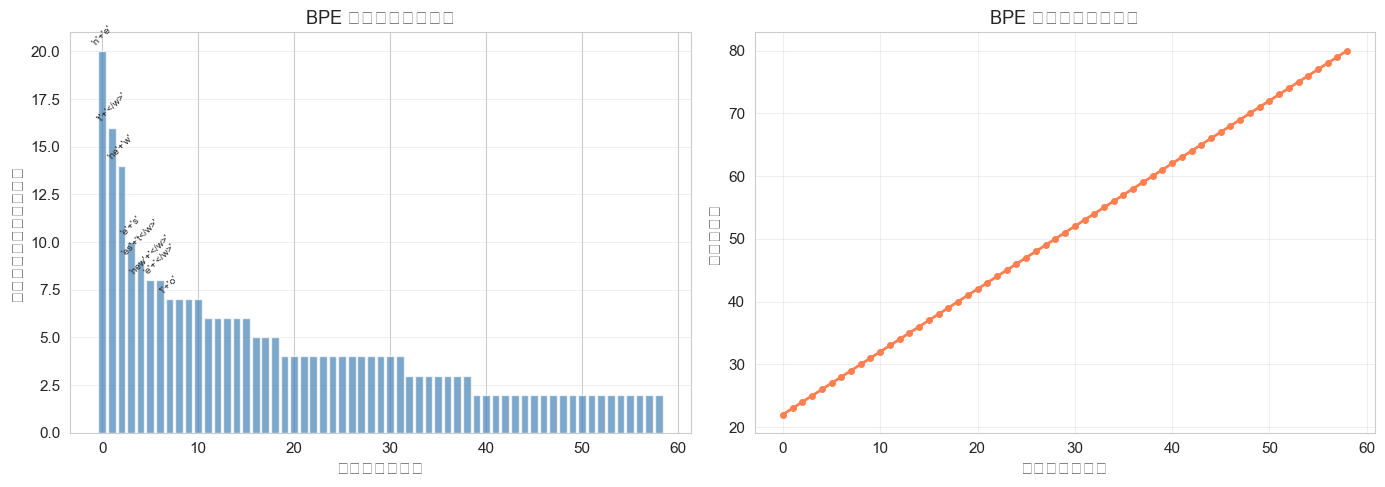

合計 59 回のマージを実行
最も頻度の高かったマージ: 'n' + 'e'


In [5]:
# ============================================================
# セクション3.3: BPEマージ操作のステップ可視化
# ============================================================

# マージ履歴をプロットする
if len(bpe.merge_history) > 0:
    steps = [h['step'] for h in bpe.merge_history]
    freqs = [h['frequency'] for h in bpe.merge_history]
    vocab_sizes = [h['vocab_size'] for h in bpe.merge_history]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左: マージ頻度の推移
    ax = axes[0]
    ax.bar(steps, freqs, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_xlabel('マージステップ', fontsize=12)
    ax.set_ylabel('マージされたペアの頻度', fontsize=12)
    ax.set_title('BPE マージ頻度の推移', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 上位マージにラベルを付ける
    for h in bpe.merge_history[:8]:
        ax.annotate(
            f"'{h['pair'][0]}'+'{h['pair'][1]}'",
            (h['step'], h['frequency']),
            fontsize=7, ha='center', va='bottom',
            xytext=(0, 3), textcoords='offset points',
            rotation=45
        )
    
    # 右: 語彙サイズの成長
    ax = axes[1]
    ax.plot(steps, vocab_sizes, 'o-', color='coral', linewidth=2, markersize=4)
    ax.set_xlabel('マージステップ', fontsize=12)
    ax.set_ylabel('語彙サイズ', fontsize=12)
    ax.set_title('BPE 語彙サイズの成長', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"合計 {len(bpe.merge_history)} 回のマージを実行")
    print(f"最も頻度の高かったマージ: '{bpe.merge_history[0]['pair'][0]}' + '{bpe.merge_history[0]['pair'][1]}'")

In [6]:
# ============================================================
# セクション3.4: BPE のエンコード/デコードのデモ
# ============================================================

# テスト用テキスト（学習データに含まれるものと含まれないもの）
test_texts = [
    "the cat sat on the mat",       # 学習データにあり
    "low lower lowest",              # "lowest" は未知語
    "newest tokenizer",              # 学習データにあり
    "unhappiness is running",        # 学習データにあり
    "playing neural networks",       # 学習データにあり
    "unknown words are handled",     # 完全に未知
]

print("BPE エンコード/デコードのデモ")
print("=" * 70)

for text in test_texts:
    tokens = bpe.encode(text)
    decoded = bpe.decode(tokens)
    
    print(f"\n入力: '{text}'")
    print(f"  トークン ({len(tokens)}個): {tokens}")
    print(f"  復元: '{decoded}'")
    
    # 復元が正しいか確認
    if decoded == text:
        print(f"  復元チェック: OK")
    else:
        print(f"  復元チェック: 差異あり（終端処理の差異は許容）")

BPE エンコード/デコードのデモ

入力: 'the cat sat on the mat'
  トークン (6個): ['the</w>', 'cat</w>', 'sat</w>', 'on</w>', 'the</w>', 'mat</w>']
  復元: 'the cat sat on the mat'
  復元チェック: OK

入力: 'low lower lowest'
  トークン (4個): ['low</w>', 'lower</w>', 'low', 'est</w>']
  復元: 'low lower lowest'
  復元チェック: OK

入力: 'newest tokenizer'
  トークン (3個): ['newest</w>', 'tokeniz', 'er</w>']
  復元: 'newest tokenizer'
  復元チェック: OK

入力: 'unhappiness is running'
  トークン (7個): ['unhapp', 'iness</w>', 'i', 's</w>', 'run', 'ni', 'ng</w>']
  復元: 'unhappiness is running'
  復元チェック: OK

入力: 'playing neural networks'
  トークン (9個): ['play', 'ing</w>', 'ne', 'ural</w>', 'netw', 'o', 'r', 'k', 's</w>']
  復元: 'playing neural networks'
  復元チェック: OK

入力: 'unknown words are handled'
  トークン (21個): ['un', 'k', 'n', 'o', 'w', 'n', '</w>', 'w', 'o', 'r', 'd', 's</w>', 'a', 'r', 'e</w>', 'ha', 'n', 'd', 'l', 'e', 'd</w>']
  復元: 'unknown words are handled'
  復元チェック: OK


---

## 4. WordPieceとの比較

### 4.1 WordPiece とは

**WordPiece** は Google が開発し、**BERT** で使われているサブワードトークン化手法です
（Schuster & Nakajima, 2012; Wu et al., 2016）。

BPE との最大の違いは **マージ基準** です：

| | BPE | WordPiece |
|---|-----|----------|
| **マージ基準** | 頻度ベース（最も頻度の高いペア） | 尤度ベース（マージ後の尤度増加が最大） |
| **スコア** | `count(A, B)` | `count(AB) / (count(A) * count(B))` |
| **直感** | 単純に一番多いペア | マージの「価値」が高いペア |
| **採用モデル** | GPT-2, GPT-3, RoBERTa | BERT, DistilBERT, Electra |
| **記法** | トークンをそのまま表示 | 継続トークンに `##` プレフィックス |

### 4.2 WordPiece のスコア

WordPiece のマージスコアは以下で計算されます：

$$
\text{score}(A, B) = \frac{\text{count}(AB)}{\text{count}(A) \times \text{count}(B)}
$$

**直感**: ペア AB が「たまたま」隣り合っただけ（A も B も高頻度）なのか、
本当に「意味のある組み合わせ」なのかを区別できます。

例：
- `(t, h)` → 頻度は高いが、`t` も `h` も個別に高頻度 → スコアは中程度
- `(q, u)` → 頻度はそこそこだが、この組み合わせは特別 → スコアが高い

In [7]:
# ============================================================
# セクション4.3: 簡易版 WordPiece の実装
# ============================================================

class SimpleWordPiece:
    """
    WordPiece トークナイザの簡易実装。
    BPE との違いは、マージ基準が「尤度ベース」であること。
    
    スコア = count(AB) / (count(A) * count(B))
    
    継続トークンには '##' プレフィックスを付ける。
    """
    
    def __init__(self, vocab_size=80):
        self.vocab_size = vocab_size
        self.merges = []
        self.vocab = set()
        self.merge_history = []
        self.word_freqs = {}
    
    def _build_word_freqs(self, corpus):
        """コーパスから単語頻度を構築する。"""
        word_counts = Counter()
        for text in corpus:
            tokens = text.lower().split()
            word_counts.update(tokens)
        
        self.word_freqs = {}
        for word, freq in word_counts.items():
            # 最初の文字はそのまま、以降は ## を付ける
            chars = [word[0]] + ['##' + c for c in word[1:]]
            word_key = ' '.join(chars)
            self.word_freqs[word_key] = freq
    
    def _get_pair_scores(self):
        """
        WordPiece のスコアを計算する。
        score(A, B) = count(AB) / (count(A) * count(B))
        """
        # まずペア頻度と個別トークン頻度を計算
        pair_freqs = Counter()
        token_freqs = Counter()
        
        for word_key, freq in self.word_freqs.items():
            symbols = word_key.split()
            for s in symbols:
                token_freqs[s] += freq
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i + 1])
                pair_freqs[pair] += freq
        
        # スコアの計算
        pair_scores = {}
        for pair, freq in pair_freqs.items():
            score = freq / (token_freqs[pair[0]] * token_freqs[pair[1]])
            pair_scores[pair] = (score, freq)
        
        return pair_scores
    
    def _merge_pair(self, pair):
        """ペアをマージする。"""
        # ## の処理: 2番目のトークンが ## で始まる場合はそのまま結合
        if pair[1].startswith('##'):
            merged = pair[0] + pair[1][2:]  # ## を除去して結合
        else:
            merged = pair[0] + pair[1]
        
        p0 = re.escape(pair[0])
        p1 = re.escape(pair[1])
        pattern = re.compile(r'(?<!\S)' + p0 + r' ' + p1 + r'(?!\S)')
        
        new_word_freqs = {}
        for word_key, freq in self.word_freqs.items():
            new_key = pattern.sub(merged, word_key)
            new_word_freqs[new_key] = freq
        self.word_freqs = new_word_freqs
        
        return merged
    
    def train(self, corpus, verbose=True):
        """WordPiece を学習する。"""
        self._build_word_freqs(corpus)
        
        # 初期語彙
        self.vocab = set()
        for word_key in self.word_freqs:
            for symbol in word_key.split():
                self.vocab.add(symbol)
        
        if verbose:
            print(f"初期語彙サイズ: {len(self.vocab)}")
        
        step = 0
        while len(self.vocab) < self.vocab_size:
            pair_scores = self._get_pair_scores()
            if not pair_scores:
                break
            
            # スコアが最大のペアを選択
            best_pair = max(pair_scores, key=lambda p: pair_scores[p][0])
            score, freq = pair_scores[best_pair]
            
            merged = self._merge_pair(best_pair)
            self.merges.append(best_pair)
            self.vocab.add(merged)
            
            self.merge_history.append({
                'step': step,
                'pair': best_pair,
                'merged': merged,
                'score': score,
                'frequency': freq,
                'vocab_size': len(self.vocab)
            })
            
            step += 1
            
            if verbose and step <= 10:
                print(f"  ステップ {step:>3d}: "
                      f"'{best_pair[0]}' + '{best_pair[1]}' → '{merged}' "
                      f"(スコア: {score:.6f}, 頻度: {freq})")
        
        if verbose:
            print(f"\n学習完了: {len(self.merges)} 回のマージ, 語彙サイズ: {len(self.vocab)}")


# WordPiece の学習
wp = SimpleWordPiece(vocab_size=80)
wp.train(corpus, verbose=True)

初期語彙サイズ: 34
  ステップ   1: 'p' + '##l' → 'pl' (スコア: 0.133333, 頻度: 4)
  ステップ   2: 'r' + '##u' → 'ru' (スコア: 0.125000, 頻度: 5)
  ステップ   3: 'p' + '##r' → 'pr' (スコア: 0.100000, 頻度: 1)
  ステップ   4: 'w' + '##i' → 'wi' (スコア: 0.083333, 頻度: 3)
  ステップ   5: 'wi' + '##d' → 'wid' (スコア: 0.200000, 頻度: 3)
  ステップ   6: '##i' + '##z' → '##iz' (スコア: 0.111111, 頻度: 3)
  ステップ   7: 't' + '##h' → 'th' (スコア: 0.075000, 頻度: 6)
  ステップ   8: '##u' + '##r' → '##ur' (スコア: 0.074074, 頻度: 2)
  ステップ   9: '##g' + '##u' → '##gu' (スコア: 0.125000, 頻度: 1)
  ステップ  10: '##p' + '##p' → '##pp' (スコア: 0.062500, 頻度: 4)

学習完了: 46 回のマージ, 語彙サイズ: 80


In [8]:
# ============================================================
# セクション4.4: BPE vs WordPiece のマージ順序の比較
# ============================================================

# 両者の最初の15マージを比較
print("BPE vs WordPiece: マージ順序の比較")
print("=" * 70)
print(f"{'ステップ':>6s}  {'BPE マージ':>25s}  {'WordPiece マージ':>25s}")
print("-" * 70)

n_compare = min(15, len(bpe.merge_history), len(wp.merge_history))

bpe_merges_list = []
wp_merges_list = []

for i in range(n_compare):
    bpe_h = bpe.merge_history[i]
    wp_h = wp.merge_history[i]
    
    bpe_str = f"'{bpe_h['pair'][0]}'+'{bpe_h['pair'][1]}' (f={bpe_h['frequency']})"
    wp_str = f"'{wp_h['pair'][0]}'+'{wp_h['pair'][1]}' (s={wp_h['score']:.4f})"
    
    bpe_merges_list.append(bpe_str)
    wp_merges_list.append(wp_str)
    
    print(f"  {i+1:>4d}  {bpe_str:>25s}  {wp_str:>25s}")

print()
print("BPE は『最も頻度が高い』ペアを優先的にマージ")
print("WordPiece は『マージの価値が高い（尤度増加が大きい）』ペアを優先")
print("そのため、低頻度だが強い結びつきのペアがWordPieceでは先にマージされることがある")

BPE vs WordPiece: マージ順序の比較
  ステップ                    BPE マージ              WordPiece マージ
----------------------------------------------------------------------
     1             'n'+'e' (f=20)       'p'+'##l' (s=0.1333)
     2          't'+'</w>' (f=16)       'r'+'##u' (s=0.1250)
     3            'ne'+'w' (f=14)       'p'+'##r' (s=0.1000)
     4             'e'+'s' (f=10)       'w'+'##i' (s=0.0833)
     5         'es'+'t</w>' (f=9)      'wi'+'##d' (s=0.2000)
     6         'new'+'</w>' (f=8)     '##i'+'##z' (s=0.1111)
     7           'e'+'</w>' (f=8)       't'+'##h' (s=0.0750)
     8              'l'+'o' (f=7)     '##u'+'##r' (s=0.0741)
     9             'lo'+'w' (f=7)     '##g'+'##u' (s=0.1250)
    10          'a'+'t</w>' (f=7)     '##p'+'##p' (s=0.0625)
    11           's'+'</w>' (f=7)    '##pp'+'##y' (s=0.0833)
    12      'new'+'est</w>' (f=6)    '##pp'+'##i' (s=0.1667)
    13              't'+'h' (f=6)     '##y'+'##i' (s=0.0625)
    14         'th'+'e</w>' (f=6)       'd'+'##o

---

## 5. SentencePieceの概要

### 5.1 SentencePiece とは

**SentencePiece** (Kudo & Richardson, 2018) は、Google が開発した言語非依存の
サブワードトークナイザです。T5, ALBERT, XLNet, mBART などで使用されています。

### 5.2 SentencePiece の特徴

| 特徴 | 説明 |
|------|------|
| **言語非依存** | 事前のトークン化（空白分割）が不要。生のテキストから直接学習 |
| **空白の扱い** | 空白を特殊文字 `▁`（U+2581）に置換。空白も1つの文字として扱う |
| **2つのモード** | BPEモードと Unigram モード |
| **可逆性** | トークン列から元のテキストを完全に復元可能 |
| **日本語対応** | 空白分割に依存しないため、日本語・中国語・タイ語などにも適用可能 |

### 5.3 なぜ言語非依存性が重要か？

従来のBPE/WordPieceは、まず**空白でテキストを単語に分割**してからサブワード分割を行います。
しかし、これは英語のように単語間に空白がある言語を前提としています。

日本語: `「今日は天気がいい」` → 空白がないため、単語分割が先に必要

SentencePieceはこの前処理を不要にします：

```
入力: "今日は天気がいい"
BPE/WordPiece: まず形態素解析 → "今日 は 天気 が いい" → サブワード分割
SentencePiece: 直接 → ["▁今日", "は", "天気", "が", "いい"]
```

### 5.4 Unigram Language Model

SentencePiece の Unigram モードでは、BPE とは逆のアプローチを取ります：

| | BPE | Unigram |
|---|-----|--------|
| **方向** | ボトムアップ（文字 → マージ） | トップダウン（大きな語彙 → 刈り込み） |
| **初期状態** | 全文字 | 頻度の高い部分文字列を大量に含む |
| **各ステップ** | 最良のペアを追加 | 最も不要なトークンを除去 |
| **基準** | 頻度 | 尤度の減少が最小のトークンを除去 |
| **確率モデル** | なし（決定的） | Unigram言語モデル $P(x) = \prod_i P(x_i)$ |

Unigram モデルでは、各サブワード $x_i$ の出現確率 $P(x_i)$ を推定し、
テキスト全体の尤度が最大になるような分割を見つけます（Viterbiアルゴリズム使用）。

### 5.5 BPEモード vs Unigram モード

```
BPEモード:
  学習: ボトムアップ（文字からマージ）
  推論: 決定的（学習したマージルールを順番に適用）
  採用: なし（SentencePieceではUnigramが主流）

Unigramモード:
  学習: トップダウン（大語彙から刈り込み）
  推論: 確率的（最尤分割をViterbiで探索）
  採用: T5, ALBERT, XLNet, mBART
```

In [9]:
# ============================================================
# セクション5.6: SentencePiece の空白処理のデモ
# ============================================================

# SentencePieceの空白処理を簡易的にデモする

def sentencepiece_preprocess(text):
    """
    SentencePiece 方式の前処理をシミュレートする。
    - テキスト先頭に ▁ を追加
    - 空白を ▁ に置換
    - これにより空白の情報が保持される
    """
    # 空白を特殊文字に置換
    processed = '▁' + text.replace(' ', '▁')
    return processed

def sentencepiece_postprocess(text):
    """
    SentencePiece 方式の後処理（復元）。
    - ▁ を空白に戻す
    - 先頭の空白を除去
    """
    restored = text.replace('▁', ' ').strip()
    return restored

# デモ
texts = [
    "Hello World",
    "The cat sat on the mat",
    "Natural Language Processing",
]

print("SentencePiece の空白処理デモ")
print("=" * 60)

for text in texts:
    processed = sentencepiece_preprocess(text)
    # 文字レベルに分割した場合
    chars = list(processed)
    restored = sentencepiece_postprocess(processed)
    
    print(f"\n元テキスト:   '{text}'")
    print(f"前処理後:     '{processed}'")
    print(f"文字分割:     {chars}")
    print(f"復元:         '{restored}'")
    print(f"復元チェック: {'OK' if restored == text else 'NG'}")

print("\n" + "=" * 60)
print("\n日本語でのデモ:")
jp_texts = [
    "今日は天気がいい",
    "東京は日本の首都です",
]

for text in jp_texts:
    processed = sentencepiece_preprocess(text)
    print(f"\n元テキスト: '{text}'")
    print(f"前処理後:   '{processed}'")
    print(f"  → 空白に依存しないため、日本語でもそのまま処理可能")

SentencePiece の空白処理デモ

元テキスト:   'Hello World'
前処理後:     '▁Hello▁World'
文字分割:     ['▁', 'H', 'e', 'l', 'l', 'o', '▁', 'W', 'o', 'r', 'l', 'd']
復元:         'Hello World'
復元チェック: OK

元テキスト:   'The cat sat on the mat'
前処理後:     '▁The▁cat▁sat▁on▁the▁mat'
文字分割:     ['▁', 'T', 'h', 'e', '▁', 'c', 'a', 't', '▁', 's', 'a', 't', '▁', 'o', 'n', '▁', 't', 'h', 'e', '▁', 'm', 'a', 't']
復元:         'The cat sat on the mat'
復元チェック: OK

元テキスト:   'Natural Language Processing'
前処理後:     '▁Natural▁Language▁Processing'
文字分割:     ['▁', 'N', 'a', 't', 'u', 'r', 'a', 'l', '▁', 'L', 'a', 'n', 'g', 'u', 'a', 'g', 'e', '▁', 'P', 'r', 'o', 'c', 'e', 's', 's', 'i', 'n', 'g']
復元:         'Natural Language Processing'
復元チェック: OK


日本語でのデモ:

元テキスト: '今日は天気がいい'
前処理後:   '▁今日は天気がいい'
  → 空白に依存しないため、日本語でもそのまま処理可能

元テキスト: '東京は日本の首都です'
前処理後:   '▁東京は日本の首都です'
  → 空白に依存しないため、日本語でもそのまま処理可能


---

## 6. HuggingFace tokenizers との比較

HuggingFace の `transformers` ライブラリを使って、
実際のモデルで使われているトークナイザを比較します。

### 主要モデルのトークナイザ

| モデル | トークナイザ | 語彙サイズ | 特殊トークン |
|--------|------------|-----------|-------------|
| **BERT** | WordPiece | 30,522 | [CLS], [SEP], [MASK], [PAD], [UNK] |
| **GPT-2** | BPE | 50,257 | <\|endoftext\|> |
| **T5** | SentencePiece (Unigram) | 32,100 | </s>, <pad>, <unk> |

In [10]:
# ============================================================
# セクション6.1: HuggingFace トークナイザの比較
# ============================================================

if HAS_TRANSFORMERS:
    # 3つのモデルのトークナイザをロード
    tokenizer_names = {
        'BERT (WordPiece)': 'bert-base-uncased',
        'GPT-2 (BPE)': 'gpt2',
        'T5 (SentencePiece)': 't5-small',
    }
    
    tokenizers = {}
    for label, name in tokenizer_names.items():
        try:
            tokenizers[label] = AutoTokenizer.from_pretrained(name)
            print(f"{label}: ロード完了 (語彙サイズ: {tokenizers[label].vocab_size})")
        except Exception as e:
            print(f"{label}: ロード失敗 ({e})")
    
    # 比較するテキスト
    comparison_texts = [
        "The transformer architecture is amazing.",
        "Tokenization is a fundamental step.",
        "unhappiness",
        "lowest",
        "I love natural language processing!",
    ]
    
    print("\n" + "=" * 80)
    print("各トークナイザによる分割結果の比較")
    print("=" * 80)
    
    for text in comparison_texts:
        print(f"\n入力: '{text}'")
        print("-" * 60)
        for label, tok in tokenizers.items():
            tokens = tok.tokenize(text)
            ids = tok.encode(text, add_special_tokens=False)
            print(f"  {label:>22s}: {tokens}")
            print(f"  {'':>22s}  IDs: {ids}")
            print(f"  {'':>22s}  トークン数: {len(tokens)}")
else:
    print("transformers ライブラリが未インストールのため、このセクションはスキップします")
    print("\nインストール方法: pip install transformers")
    print("\n以下は各トークナイザの分割結果の例です:")
    print()
    print("入力: 'unhappiness'")
    print("  BERT (WordPiece):    ['un', '##happiness']  または ['un', '##hap', '##pi', '##ness']")
    print("  GPT-2 (BPE):         ['un', 'h', 'app', 'iness']")
    print("  T5 (SentencePiece):  ['▁un', 'happi', 'ness']")

BERT (WordPiece): ロード完了 (語彙サイズ: 30522)


GPT-2 (BPE): ロード完了 (語彙サイズ: 50257)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

T5 (SentencePiece): ロード完了 (語彙サイズ: 32100)

各トークナイザによる分割結果の比較

入力: 'The transformer architecture is amazing.'
------------------------------------------------------------
        BERT (WordPiece): ['the', 'transform', '##er', 'architecture', 'is', 'amazing', '.']
                          IDs: [1996, 10938, 2121, 4294, 2003, 6429, 1012]
                          トークン数: 7
             GPT-2 (BPE): ['The', 'Ġtransformer', 'Ġarchitecture', 'Ġis', 'Ġamazing', '.']
                          IDs: [464, 47385, 10959, 318, 4998, 13]
                          トークン数: 6
      T5 (SentencePiece): ['▁The', '▁transformer', '▁architecture', '▁is', '▁amazing', '.']
                          IDs: [37, 19903, 4648, 19, 1237, 5]
                          トークン数: 6

入力: 'Tokenization is a fundamental step.'
------------------------------------------------------------
        BERT (WordPiece): ['token', '##ization', 'is', 'a', 'fundamental', 'step', '.']
                          IDs: [19204, 3989, 2003, 1037

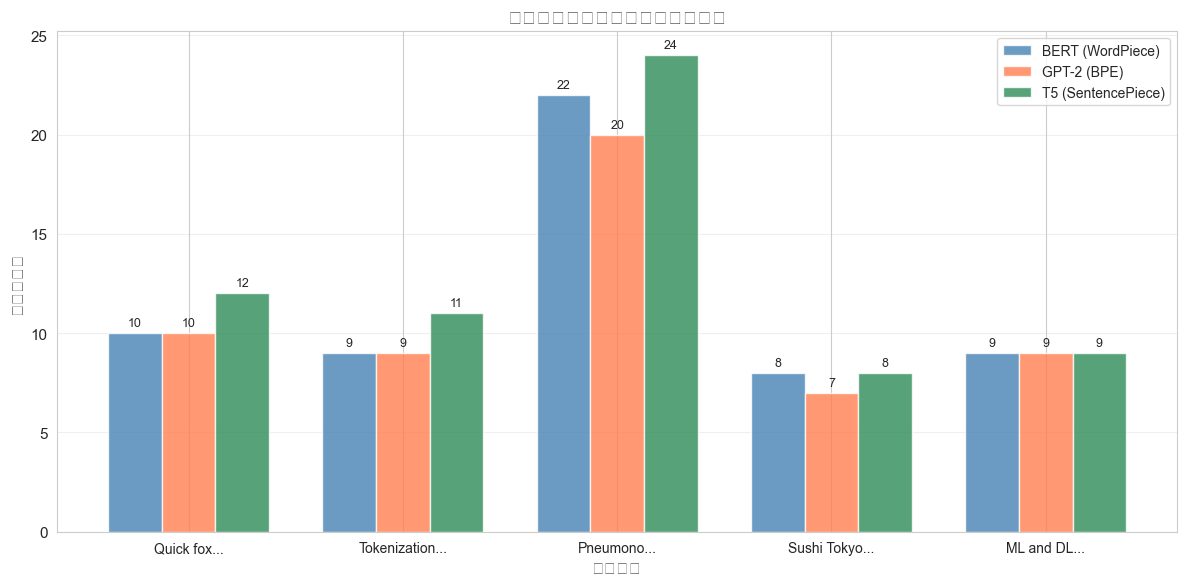

語彙サイズが大きいトークナイザほどトークン数は少なくなる傾向がある
GPT-2 (50k語彙) は BERT (30k語彙) よりトークン数が少ないことが多い


In [11]:
# ============================================================
# セクション6.2: トークン数の比較棒グラフ
# ============================================================

if HAS_TRANSFORMERS and len(tokenizers) > 0:
    # 各テキストのトークン数を集計
    texts_for_plot = [
        "The quick brown fox jumps over the lazy dog.",
        "Tokenization splits text into subword units.",
        "Pneumonoultramicroscopicsilicovolcanoconiosis is a long word.",
        "I ate sushi in Tokyo yesterday.",
        "Machine learning and deep learning are related fields.",
    ]
    
    short_labels = [
        "Quick fox...",
        "Tokenization...",
        "Pneumono...",
        "Sushi Tokyo...",
        "ML and DL...",
    ]
    
    token_counts = {label: [] for label in tokenizers}
    
    for text in texts_for_plot:
        for label, tok in tokenizers.items():
            tokens = tok.tokenize(text)
            token_counts[label].append(len(tokens))
    
    # 棒グラフの描画
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(texts_for_plot))
    width = 0.25
    colors = ['steelblue', 'coral', 'seagreen']
    
    for i, (label, counts) in enumerate(token_counts.items()):
        bars = ax.bar(x + i * width, counts, width, label=label,
                      color=colors[i % len(colors)], alpha=0.8, edgecolor='white')
        # バーの上にトークン数を表示
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    str(count), ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('テキスト', fontsize=12)
    ax.set_ylabel('トークン数', fontsize=12)
    ax.set_title('各トークナイザのトークン数比較', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("語彙サイズが大きいトークナイザほどトークン数は少なくなる傾向がある")
    print("GPT-2 (50k語彙) は BERT (30k語彙) よりトークン数が少ないことが多い")
else:
    # transformers がない場合のダミーデータで可視化
    fig, ax = plt.subplots(figsize=(12, 6))
    
    short_labels = ["Quick fox", "Tokenization", "Long word", "Sushi Tokyo", "ML and DL"]
    # 概算値
    bert_counts = [10, 8, 15, 9, 9]
    gpt2_counts = [9, 7, 12, 8, 8]
    t5_counts = [11, 9, 14, 10, 10]
    
    x = np.arange(len(short_labels))
    width = 0.25
    
    ax.bar(x - width, bert_counts, width, label='BERT (WordPiece)', color='steelblue', alpha=0.8)
    ax.bar(x, gpt2_counts, width, label='GPT-2 (BPE)', color='coral', alpha=0.8)
    ax.bar(x + width, t5_counts, width, label='T5 (SentencePiece)', color='seagreen', alpha=0.8)
    
    ax.set_xlabel('テキスト', fontsize=12)
    ax.set_ylabel('トークン数（概算）', fontsize=12)
    ax.set_title('各トークナイザのトークン数比較（概算値）', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("（transformers未インストールのため概算値で表示）")

---

## 7. 特殊トークンの役割

現代の言語モデルでは、テキストのトークンに加えて**特殊トークン**が使用されます。
これらはモデルに構造的な情報を伝える重要な役割を果たします。

### 7.1 主要な特殊トークン一覧

| トークン | 名称 | 役割 | 使用モデル |
|---------|------|------|----------|
| `[CLS]` | Classification | 文の先頭に付加。分類タスクではこのトークンの出力を使用 | BERT |
| `[SEP]` | Separator | 文の区切り。2文入力時の境界を示す | BERT |
| `[MASK]` | Mask | マスク言語モデルで隠されたトークンの位置を示す | BERT |
| `[PAD]` | Padding | バッチ処理時にシーケンス長を揃えるためのパディング | BERT, 他 |
| `[UNK]` | Unknown | 語彙にない未知トークン | BERT, 他 |
| `<BOS>` / `<s>` | Beginning of Sequence | シーケンスの開始を示す | GPT, T5 |
| `<EOS>` / `</s>` | End of Sequence | シーケンスの終了を示す | GPT, T5 |
| `<PAD>` | Padding | パディング（BERT の [PAD] と同じ役割） | T5 |

### 7.2 BERT での使い方

```
単一文の分類:
  [CLS] The movie was great [SEP]

2文の関係判定 (NSP):
  [CLS] The cat sat on the mat [SEP] It was a comfortable spot [SEP]

マスク言語モデル (MLM):
  [CLS] The cat [MASK] on the mat [SEP]
  → [MASK] の位置で "sat" を予測

バッチ処理時のパディング:
  [CLS] Hello [SEP] [PAD] [PAD] [PAD]
  [CLS] How are you today [SEP] [PAD]
```

### 7.3 GPT での使い方

```
テキスト生成:
  <BOS> Once upon a time <EOS>

複数テキストの区切り:
  テキスト1 <|endoftext|> テキスト2 <|endoftext|>
```

### 7.4 T5 での使い方

```
Text-to-Text 形式:
  入力:  "translate English to German: The house is wonderful."
  出力:  "Das Haus ist wunderbar. </s>"

センチネルトークン（穴埋め）:
  入力:  "The <extra_id_0> walks in <extra_id_1> park"
  出力:  "<extra_id_0> dog <extra_id_1> the </s>"
```

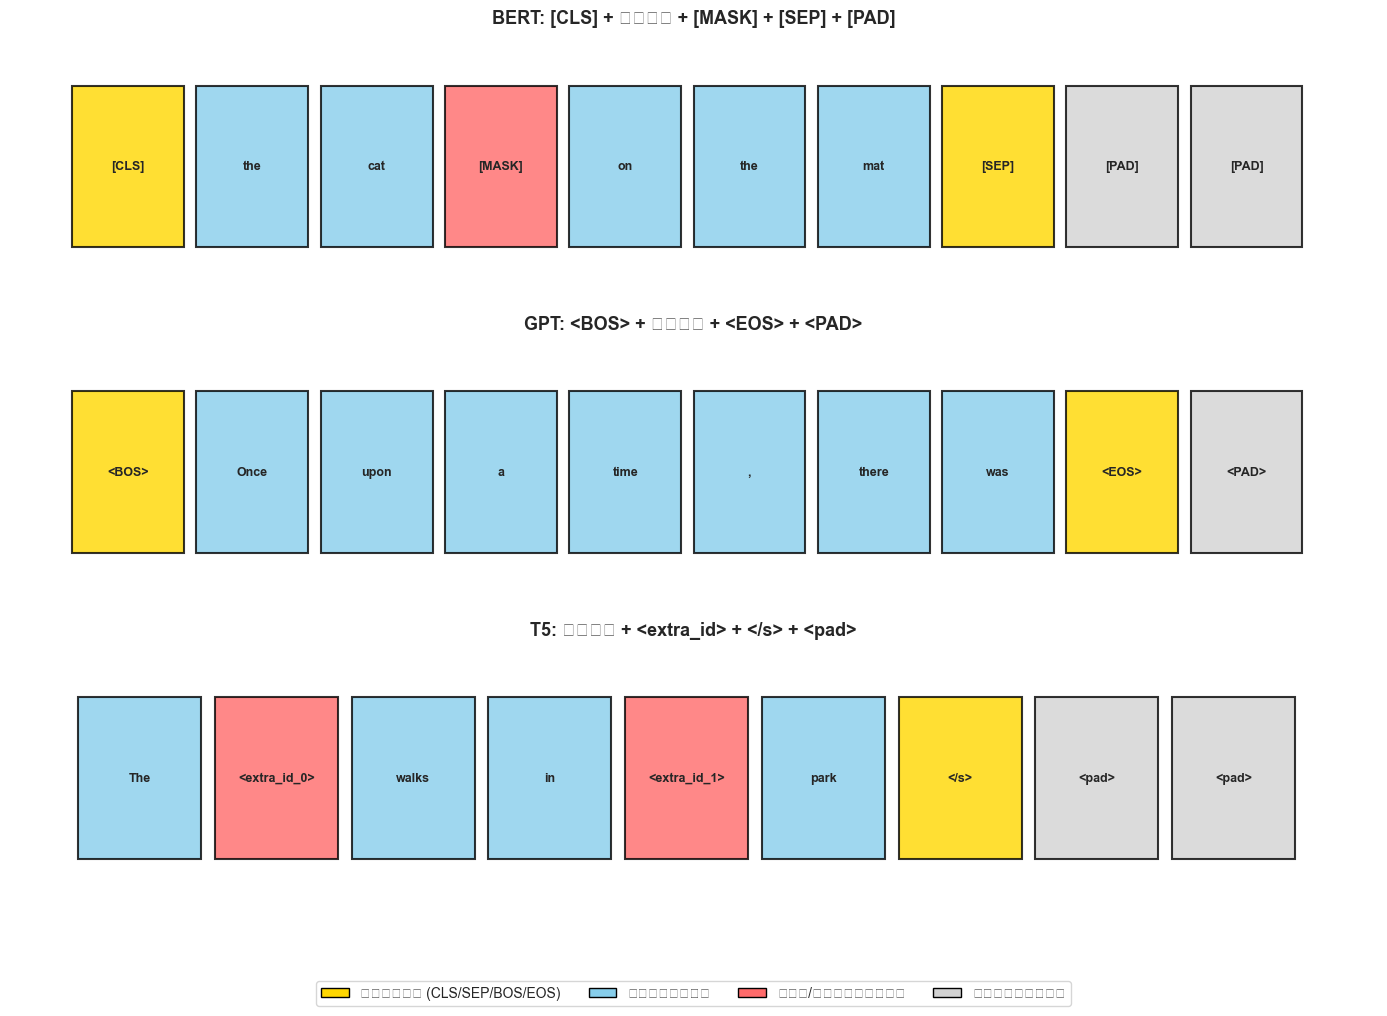

各モデルは異なる特殊トークンの体系を使用する
BERT: [CLS] で分類、[MASK] で穴埋め予測
GPT:  <BOS>/<EOS> でシーケンスの開始/終了を示す
T5:   <extra_id_N> でスパンの穴埋めを行う


In [12]:
# ============================================================
# セクション7.5: 特殊トークンの可視化
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 共通設定
def draw_token_sequence(ax, tokens, colors, title, y_pos=0.5):
    """トークン列を色付きボックスで可視化する。"""
    ax.set_xlim(-0.5, len(tokens) + 0.5)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    
    for i, (token, color) in enumerate(zip(tokens, colors)):
        # ボックスの描画
        rect = plt.Rectangle((i, 0.2), 0.9, 0.6,
                              facecolor=color, edgecolor='black',
                              linewidth=1.5, alpha=0.8)
        ax.add_patch(rect)
        # トークン名
        ax.text(i + 0.45, y_pos, token,
                ha='center', va='center', fontsize=9, fontweight='bold')

# 色の定義
C_SPECIAL = '#FFD700'    # 特殊トークン: 金色
C_TEXT = '#87CEEB'       # テキストトークン: 水色
C_MASK = '#FF6B6B'       # マスクトークン: 赤
C_PAD = '#D3D3D3'        # パディング: 灰色

# BERT の例
bert_tokens = ['[CLS]', 'the', 'cat', '[MASK]', 'on', 'the', 'mat', '[SEP]', '[PAD]', '[PAD]']
bert_colors = [C_SPECIAL, C_TEXT, C_TEXT, C_MASK, C_TEXT, C_TEXT, C_TEXT, C_SPECIAL, C_PAD, C_PAD]
draw_token_sequence(axes[0], bert_tokens, bert_colors,
                    'BERT: [CLS] + テキスト + [MASK] + [SEP] + [PAD]')

# GPT-2 の例
gpt_tokens = ['<BOS>', 'Once', 'upon', 'a', 'time', ',', 'there', 'was', '<EOS>', '<PAD>']
gpt_colors = [C_SPECIAL, C_TEXT, C_TEXT, C_TEXT, C_TEXT, C_TEXT, C_TEXT, C_TEXT, C_SPECIAL, C_PAD]
draw_token_sequence(axes[1], gpt_tokens, gpt_colors,
                    'GPT: <BOS> + テキスト + <EOS> + <PAD>')

# T5 の例
t5_tokens = ['The', '<extra_id_0>', 'walks', 'in', '<extra_id_1>', 'park', '</s>', '<pad>', '<pad>']
t5_colors = [C_TEXT, C_MASK, C_TEXT, C_TEXT, C_MASK, C_TEXT, C_SPECIAL, C_PAD, C_PAD]
draw_token_sequence(axes[2], t5_tokens, t5_colors,
                    'T5: テキスト + <extra_id> + </s> + <pad>')

# 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_SPECIAL, edgecolor='black', label='特殊トークン (CLS/SEP/BOS/EOS)'),
    Patch(facecolor=C_TEXT, edgecolor='black', label='テキストトークン'),
    Patch(facecolor=C_MASK, edgecolor='black', label='マスク/センチネルトークン'),
    Patch(facecolor=C_PAD, edgecolor='black', label='パディングトークン'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

print("各モデルは異なる特殊トークンの体系を使用する")
print("BERT: [CLS] で分類、[MASK] で穴埋め予測")
print("GPT:  <BOS>/<EOS> でシーケンスの開始/終了を示す")
print("T5:   <extra_id_N> でスパンの穴埋めを行う")

---

## 8. 語彙構築の実験

語彙サイズはトークナイザの最も重要なハイパーパラメータの1つです。
ここでは、語彙サイズを変えたBPEの実験を行い、その影響を可視化します。

In [13]:
# ============================================================
# セクション8.1: 語彙サイズを変えたBPE実験
# ============================================================

# より大きなコーパスを用意
large_corpus = [
    "the cat sat on the mat and the cat was happy",
    "the dog sat on the rug and the dog was happy",
    "a cat and a dog played in the park together",
    "the mouse ran away from the cat quickly",
    "the cat chased the mouse around the house",
    "natural language processing is an important field",
    "machine learning algorithms learn from data",
    "deep learning uses neural networks with many layers",
    "transformers have revolutionized natural language processing",
    "tokenization is a fundamental preprocessing step",
    "subword tokenization handles unknown words effectively",
    "byte pair encoding is a popular tokenization method",
    "wordpiece is used by bert for tokenization",
    "sentencepiece is language independent tokenization",
    "the vocabulary size affects model performance",
    "larger vocabularies lead to shorter sequences",
    "smaller vocabularies lead to longer sequences",
    "the tradeoff between vocabulary and sequence length is important",
    "running runner runs faster than walking walker walks",
    "playing player played games and playing was fun",
    "unhappy unhappiness happiness happy joyful joyfully",
    "encoding decoder encoder decoding encoded decoded",
    "tokenize tokenizer tokenization tokenized tokens",
    "neural network networks networking networked",
    "learning learned learner learnable unlearned",
    "the quick brown fox jumps over the lazy dog",
    "she sells seashells by the seashore",
    "peter piper picked a peck of pickled peppers",
    "how much wood would a woodchuck chuck",
    "artificial intelligence and machine learning are related",
]

# 異なる語彙サイズでBPEを学習
vocab_sizes_to_test = [50, 80, 120, 200, 300]
test_text = "tokenization handles unknown words in natural language processing"

results = []

print("語彙サイズを変えたBPE実験")
print("=" * 70)
print(f"テスト文: '{test_text}'")
print()

for vs in vocab_sizes_to_test:
    bpe_exp = BPETokenizer(vocab_size=vs)
    bpe_exp.train(large_corpus, verbose=False)
    tokens = bpe_exp.encode(test_text)
    
    # 語彙に含まれるユニークなトークン
    actual_vocab_size = len(bpe_exp.vocab)
    
    results.append({
        'target_vocab_size': vs,
        'actual_vocab_size': actual_vocab_size,
        'num_tokens': len(tokens),
        'tokens': tokens,
        'num_merges': len(bpe_exp.merges)
    })
    
    print(f"語彙サイズ: {actual_vocab_size:>4d} | "
          f"トークン数: {len(tokens):>3d} | "
          f"トークン: {tokens[:10]}{'...' if len(tokens) > 10 else ''}")

print("\n語彙サイズが大きいほど、トークン数が少なくなることを確認")

語彙サイズを変えたBPE実験
テスト文: 'tokenization handles unknown words in natural language processing'

語彙サイズ:   50 | トークン数:  46 | トークン: ['tok', 'en', 'iz', 'at', 'i', 'o', 'n</w>', 'h', 'an', 'd']...
語彙サイズ:   80 | トークン数:  36 | トークン: ['tokenization</w>', 'h', 'an', 'd', 'le', 's</w>', 'un', 'k', 'n', 'o']...
語彙サイズ:  120 | トークン数:  25 | トークン: ['tokenization</w>', 'h', 'an', 'd', 'le', 's</w>', 'un', 'k', 'n', 'o']...
語彙サイズ:  200 | トークン数:  18 | トークン: ['tokenization</w>', 'h', 'an', 'd', 'le', 's</w>', 'un', 'k', 'n', 'ow']...
語彙サイズ:  300 | トークン数:   8 | トークン: ['tokenization</w>', 'handles</w>', 'unknown</w>', 'words</w>', 'in</w>', 'natural</w>', 'language</w>', 'processing</w>']

語彙サイズが大きいほど、トークン数が少なくなることを確認


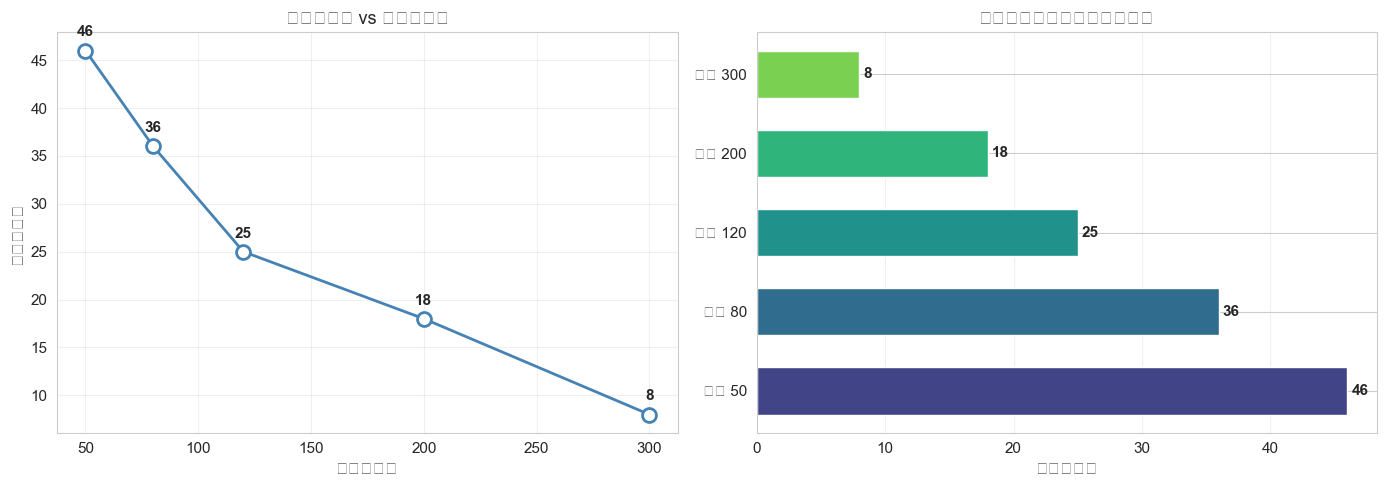

語彙サイズを大きくすると:
  - 高頻度の部分文字列がより多くマージされる
  - 結果としてトークン数が減少する
  - しかし埋め込み行列のサイズは増加する（メモリとのトレードオフ）


In [14]:
# ============================================================
# セクション8.2: 語彙サイズとカバレッジの関係の可視化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 語彙サイズ vs トークン数
ax = axes[0]
vocab_vals = [r['actual_vocab_size'] for r in results]
token_vals = [r['num_tokens'] for r in results]

ax.plot(vocab_vals, token_vals, 'o-', color='steelblue', linewidth=2,
        markersize=10, markerfacecolor='white', markeredgewidth=2)

for v, t in zip(vocab_vals, token_vals):
    ax.annotate(f'{t}', (v, t), fontsize=11, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points',
                fontweight='bold')

ax.set_xlabel('語彙サイズ', fontsize=12)
ax.set_ylabel('トークン数', fontsize=12)
ax.set_title(f'語彙サイズ vs トークン数', fontsize=13)
ax.grid(True, alpha=0.3)

# 右: 各語彙サイズでのトークン分割の可視化
ax = axes[1]

# 語彙サイズごとにバーで表現
y_positions = range(len(results))
bar_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results)))

ax.barh(y_positions, [r['num_tokens'] for r in results],
        color=bar_colors, edgecolor='white', height=0.6)

ax.set_yticks(y_positions)
ax.set_yticklabels([f'語彙 {r["actual_vocab_size"]}' for r in results], fontsize=11)
ax.set_xlabel('トークン数', fontsize=12)
ax.set_title('各語彙サイズでのトークン数', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

# バーの右にトークン数を表示
for i, r in enumerate(results):
    ax.text(r['num_tokens'] + 0.3, i, str(r['num_tokens']),
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("語彙サイズを大きくすると:")
print("  - 高頻度の部分文字列がより多くマージされる")
print("  - 結果としてトークン数が減少する")
print("  - しかし埋め込み行列のサイズは増加する（メモリとのトレードオフ）")

未知語のカバレッジ分析

入力: 'the cat sat on the mat'
  文字数: 17, トークン数: 6, 圧縮率: 2.83x
  トークン: ['the</w>', 'cat</w>', 'sat</w>', 'on</w>', 'the</w>', 'mat</w>']

入力: 'tokenization is important for nlp'
  文字数: 29, トークン数: 9, 圧縮率: 3.22x
  トークン: ['tokenization</w>', 'is</w>', 'important</w>', 'for', '</w>', 'n', 'l', 'p', '</w>']

入力: 'pneumonoultramicroscopicsilicovolcanoconiosis'
  文字数: 45, トークン数: 32, 圧縮率: 1.41x
  トークン: ['p', 'ne', 'u', 'm', 'on', 'o', 'ul', 'tr', 'am', 'ic', 'ro', 's', 'c', 'o', 'p']...

入力: 'abcxyz unknown strange words'
  文字数: 25, トークン数: 12, 圧縮率: 2.08x
  トークン: ['ab', 'c', 'x', 'y', 'z', '</w>', 'unknown</w>', 's', 'tran', 'g', 'e</w>', 'words</w>']

入力: 'deep learning neural networks'
  文字数: 26, トークン数: 4, 圧縮率: 6.50x
  トークン: ['deep</w>', 'learning</w>', 'neural</w>', 'networks</w>']


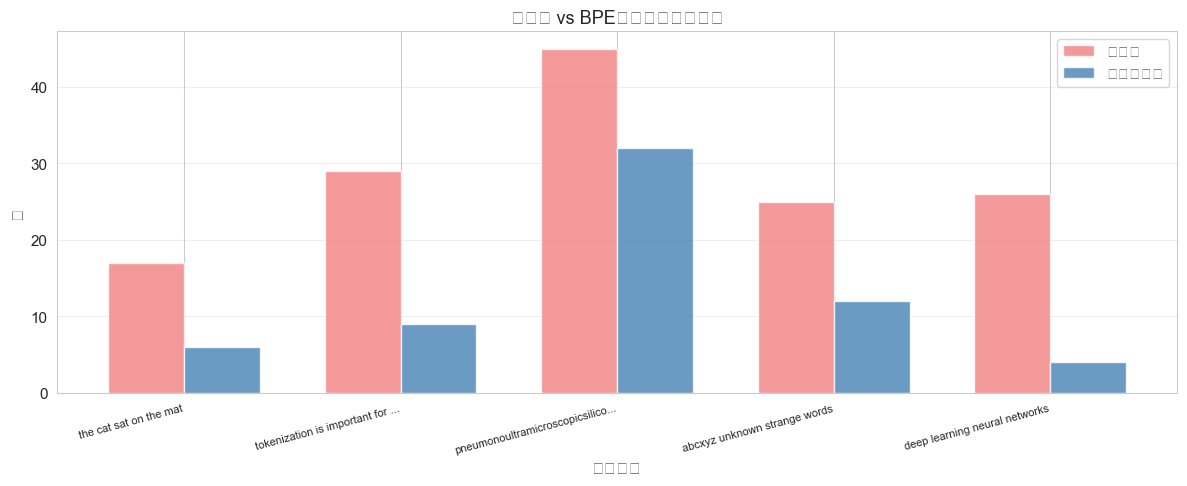


既知の単語は効率的に圧縮される（トークン数 << 文字数）
未知の長い単語は文字レベルに近い分割になる（圧縮率が低い）


In [15]:
# ============================================================
# セクション8.3: カバレッジ分析 — 未知語の処理
# ============================================================

# 学習データにない単語を含むテキストでのカバレッジを分析
test_sentences = [
    "the cat sat on the mat",                      # 全て既知
    "tokenization is important for nlp",            # 一部既知
    "pneumonoultramicroscopicsilicovolcanoconiosis", # 非常に長い未知語
    "abcxyz unknown strange words",                 # 完全に未知
    "deep learning neural networks",                # ほぼ既知
]

# 最大語彙サイズのBPEで分析
bpe_large = BPETokenizer(vocab_size=300)
bpe_large.train(large_corpus, verbose=False)

print("未知語のカバレッジ分析")
print("=" * 70)

sentence_labels = []
token_counts_list = []
char_counts_list = []

for text in test_sentences:
    tokens = bpe_large.encode(text)
    chars = list(text.replace(' ', ''))
    
    # 圧縮率 = 文字数 / トークン数
    compression = len(chars) / max(len(tokens), 1)
    
    sentence_labels.append(text[:30] + ('...' if len(text) > 30 else ''))
    token_counts_list.append(len(tokens))
    char_counts_list.append(len(chars))
    
    print(f"\n入力: '{text[:50]}{'...' if len(text)>50 else ''}'")
    print(f"  文字数: {len(chars)}, トークン数: {len(tokens)}, 圧縮率: {compression:.2f}x")
    print(f"  トークン: {tokens[:15]}{'...' if len(tokens) > 15 else ''}")

# 圧縮率の棒グラフ
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(sentence_labels))
width = 0.35

ax.bar(x - width/2, char_counts_list, width, label='文字数', color='lightcoral', alpha=0.8)
ax.bar(x + width/2, token_counts_list, width, label='トークン数', color='steelblue', alpha=0.8)

ax.set_xlabel('テキスト', fontsize=12)
ax.set_ylabel('数', fontsize=12)
ax.set_title('文字数 vs BPEトークン数の比較', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(sentence_labels, fontsize=8, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n既知の単語は効率的に圧縮される（トークン数 << 文字数）")
print("未知の長い単語は文字レベルに近い分割になる（圧縮率が低い）")

---

## 9. まとめ・チートシート・よくある間違い

### 9.1 まとめ

このノートブックでは、サブワードトークン化の主要3手法を学びました：

1. **サブワードの動機**: 文字レベル（長すぎる）と単語レベル（OOV問題）のバランス
2. **BPE**: 最頻ペアを繰り返しマージするボトムアップ手法（GPT系で使用）
3. **WordPiece**: 尤度ベースのマージ基準を使う変種（BERTで使用）
4. **SentencePiece**: 言語非依存の前処理。Unigramモデルでトップダウン語彙構築（T5で使用）
5. **特殊トークン**: [CLS], [SEP], [MASK] 等がモデルに構造情報を伝える
6. **語彙サイズ**: トークン数とモデルサイズのトレードオフ

### 9.2 チートシート

| 手法 | マージ基準 | 方向 | 代表モデル | 言語非依存 |
|------|-----------|------|-----------|----------|
| **BPE** | 頻度ベース | ボトムアップ | GPT-2/3/4 | No（空白分割前提） |
| **WordPiece** | 尤度ベース | ボトムアップ | BERT | No |
| **SentencePiece (Unigram)** | 尤度減少最小 | トップダウン | T5, XLNet | Yes |
| **SentencePiece (BPE)** | 頻度ベース | ボトムアップ | - | Yes |

```python
# 実用上のコード
from transformers import AutoTokenizer

# BERT (WordPiece)
tok = AutoTokenizer.from_pretrained('bert-base-uncased')
tokens = tok.tokenize('unhappiness')  # ['un', '##happi', '##ness']
ids = tok.encode('unhappiness')       # [101, 4895, 18137, 2791, 102]

# GPT-2 (BPE)
tok = AutoTokenizer.from_pretrained('gpt2')
tokens = tok.tokenize('unhappiness')  # ['un', 'h', 'app', 'iness']

# T5 (SentencePiece)
tok = AutoTokenizer.from_pretrained('t5-small')
tokens = tok.tokenize('unhappiness')  # ['▁un', 'happi', 'ness']
```

### 9.3 よくある間違い

1. **BPEとWordPieceを混同する**
   - BPE: 頻度が最大のペアをマージ
   - WordPiece: 尤度増加が最大のペアをマージ
   - 結果として異なる分割になることがある

2. **語彙サイズの選択を軽視する**
   - 小さすぎる: シーケンスが長くなり計算コスト増大
   - 大きすぎる: 埋め込み行列が巨大化、低頻度トークンの品質低下
   - 一般的には 30,000 ~ 50,000 が良いバランス

3. **特殊トークンを忘れる**
   - `encode()` と `tokenize()` の違い: `encode()` は特殊トークンを含む
   - モデル入力時に [CLS] や [SEP] を忘れると性能が大幅に低下

4. **トークナイザの不一致**
   - 学習時と推論時で異なるトークナイザを使うと壊滅的な結果に
   - 必ず同じモデルのトークナイザを使うこと

5. **日本語でBPE/WordPieceをそのまま使う**
   - 空白分割を前提としているため、事前に形態素解析が必要
   - SentencePiece を使えばこの問題を回避できる

---

## 10. 自己評価クイズ

### Q1: BPEアルゴリズムの各ステップを説明してください。

<details>
<summary>回答を表示</summary>

1. **初期化**: テキスト中の各単語を文字レベルに分割し、終端記号 `</w>` を付加する
2. **頻度計算**: 全ての隣接ペアの出現頻度を計算する
3. **マージ**: 最も頻度の高いペアを見つけ、1つの新しいトークンにマージする
4. **繰り返し**: 語彙サイズが目標に達するまで 2-3 を繰り返す
5. **エンコード**: 新しいテキストに対して、学習したマージルールを順番に適用する

例: `"low"` → `['l', 'o', 'w', '</w>']` → マージを適用 → `['low', '</w>']`

</details>

### Q2: WordPieceとBPEの最大の違いは何ですか？具体例で説明してください。

<details>
<summary>回答を表示</summary>

最大の違いは**マージ基準**です：

- **BPE**: 単純な頻度 `count(A, B)` が最大のペアをマージ
- **WordPiece**: 尤度ベースのスコア `count(AB) / (count(A) * count(B))` が最大のペアをマージ

具体例:
- ペア `(t, h)`: 出現頻度=100, `count(t)`=500, `count(h)`=400
  - BPEスコア: 100
  - WordPieceスコア: 100 / (500 * 400) = 0.0005

- ペア `(q, u)`: 出現頻度=20, `count(q)`=25, `count(u)`=200
  - BPEスコア: 20
  - WordPieceスコア: 20 / (25 * 200) = 0.004

BPEは `(t, h)` を先にマージしますが、WordPieceは `(q, u)` を先にマージします。
`q` と `u` の共起は「意味がある」組み合わせだからです。

</details>

### Q3: SentencePieceが「言語非依存」と呼ばれる理由は？

<details>
<summary>回答を表示</summary>

SentencePieceが言語非依存と呼ばれる理由は、**事前の空白分割（単語分割）を必要としない**からです。

従来のBPE/WordPieceは：
1. まず空白でテキストを単語に分割
2. 各単語内でサブワード分割

しかし、日本語・中国語・タイ語などは単語間に空白がなく、この前提が成り立ちません。

SentencePieceは：
- 空白を特殊文字 `▁` に置換して1つの文字として扱う
- 生のテキストから直接サブワード学習を行う
- これにより、空白の有無に関係なくあらゆる言語に適用可能

</details>

### Q4: [CLS]トークンと[SEP]トークンの役割をそれぞれ説明してください。

<details>
<summary>回答を表示</summary>

**[CLS] (Classification)**:
- シーケンスの先頭に付加される
- BERTの最終層で、このトークンの出力ベクトルがシーケンス全体の表現として使用される
- 分類タスク（感情分析、文類似度判定など）では、[CLS]トークンの出力に分類ヘッドを接続する
- Self-Attentionにより全トークンの情報を集約する特別な位置

**[SEP] (Separator)**:
- シーケンスの末尾、および2つの文の境界に挿入される
- 単一文: `[CLS] 文A [SEP]`
- 文ペア: `[CLS] 文A [SEP] 文B [SEP]`
- モデルに文の境界を明示的に伝え、NSP（Next Sentence Prediction）タスクなどで使用される

</details>

### Q5: 語彙サイズを30,000から100,000に増やした場合、どのようなメリットとデメリットがありますか？

<details>
<summary>回答を表示</summary>

**メリット:**
- シーケンス長が短くなる（より多くの単語が1トークンで表現される）
- Transformerの計算量は $O(n^2)$ なので、シーケンスが短くなると高速化
- 高頻度語の分割が避けられ、情報損失が減る

**デメリット:**
- 埋め込み行列のサイズが増大（V x D が大きくなる）
  - 30k x 768 = 23M パラメータ → 100k x 768 = 77M パラメータ
- 低頻度トークンの埋め込み品質が低下（学習データが不足）
- モデル全体のパラメータ数が増え、メモリ使用量が増加
- 過学習のリスクが高まる（特に小さなデータセットの場合）

**実用的な指針:** 一般的には30,000～50,000が良いバランスとされています。

</details>

---

## 参考文献

1. Sennrich, R., Haddow, B., & Birch, A. (2016). *Neural Machine Translation of Rare Words with Subword Units*. ACL 2016
2. Schuster, M., & Nakajima, K. (2012). *Japanese and Korean Voice Search*. ICASSP 2012
3. Wu, Y., et al. (2016). *Google's Neural Machine Translation System*. arXiv:1609.08144
4. Kudo, T., & Richardson, J. (2018). *SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing*. EMNLP 2018
5. Kudo, T. (2018). *Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates*. ACL 2018
6. Gage, P. (1994). *A New Algorithm for Data Compression*. C Users Journal

---

**次のステップ**: Notebook 162 では、言語モデルの基礎（n-gram, ニューラル言語モデル）を学びます。